# Band networks: shared members and record labels

## tl;dr

The mapped portion of the popularity-first top-1,000 catalogue yields **272
shared-member band pairs** and **5786 shared-label pairs**.
Only **240/660 mapped bands** connect through a
documented shared member, compared with **519/660**
through a shared label. In London, **36%**
of selected bands have a shared-member link and **82%**
have either type. Label networks are much denser and should not be mistaken for
local collaboration networks.

## Context & Methods

The network branch combines MusicBrainz `member of band` relationships with
Wikidata `record label` (`P264`) claims for the defensibly mapped bands in the
popularity-first top 1,000. Two selected bands are linked when they
share at least one documented member or label. The experiment reports the two
link types separately and records source coverage for every city.

### Key Assumptions

An absent relationship means undocumented in the frozen sources, not no
relationship. Shared labels can reflect distribution history rather than a
city scene. Producers, venues, educational institutions and informal
collaborations remain outside this first network.

Source documentation: [MusicBrainz API](https://musicbrainz.org/doc/MusicBrainz_API)
and [MusicBrainz relationships](https://musicbrainz.org/doc/Relationships).

## Data

Construct affiliations, band-pair edges and city summaries.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src/python_uk_bands").exists():
    ROOT = next(
        parent for parent in Path.cwd().resolve().parents
        if (parent / "src/python_uk_bands").exists()
    )
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ARTIFACT_DIR = ROOT / "artifacts/experiments/band_networks/20260725"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
from python_uk_bands.review_extension_experiments import (
    build_band_networks,
    plot_network_city_matrix,
    plot_network_connected_share,
)

WIKIDATA_PATH = ROOT / "data/raw/wikidata/review_extension_entities_20260725.json"
MUSICBRAINZ_PATH = ROOT / "data/raw/musicbrainz/review_extension_artists_20260725.json"
nodes, affiliations, edges, city_network, city_matrix, coverage = build_band_networks(
    ROOT,
    wikidata_path=WIKIDATA_PATH,
    musicbrainz_path=MUSICBRAINZ_PATH,
)

assert coverage["selected_bands"] == 1000
assert len(nodes) == coverage["mapped_bands"]
assert nodes["band_name"].is_unique
assert not affiliations.duplicated(
    ["band_name", "affiliation_type", "entity_id"]
).any()
assert not edges.duplicated(["band_a", "band_b"]).any()
assert city_network["connected_band_share"].between(0, 1).all()

nodes.to_csv(ARTIFACT_DIR / "band_network_nodes.csv", index=False)
affiliations.to_csv(ARTIFACT_DIR / "band_affiliations.csv", index=False)
edges.to_csv(ARTIFACT_DIR / "band_network_edges.csv", index=False)
city_network.to_csv(ARTIFACT_DIR / "city_network_summary.csv", index=False)
city_matrix.to_csv(ARTIFACT_DIR / "city_connection_matrix.csv", index=False)
(ARTIFACT_DIR / "coverage_summary.json").write_text(
    json.dumps(coverage, indent=2, sort_keys=True) + "\n"
)

display(Markdown(
    f"**{coverage['musicbrainz_covered_bands']}/{coverage['mapped_bands']} mapped-band member-source coverage · "
    f"{coverage['wikidata_label_covered_bands']}/{coverage['mapped_bands']} mapped-band label-source coverage · "
    f"{coverage['member_edges']} member edges · {coverage['label_edges']} label edges**"
))

**659/660 mapped-band member-source coverage · 660/660 mapped-band label-source coverage · 272 member edges · 5786 label edges**

## Results

### 1. Which selected bands share the strongest documented links?

In [3]:
display(edges.sort_values(
    ["shared_member_count", "connection_count", "band_a", "band_b"],
    ascending=[False, False, True, True],
).head(30).style.hide(axis="index"))

display(city_network.nlargest(30, "selected_bands").style.hide(axis="index").format({
    "connected_band_share": "{:.0%}",
    "member_connected_band_share": "{:.0%}",
    "label_connected_band_share": "{:.0%}",
    "member_source_coverage": "{:.0%}",
    "label_source_coverage": "{:.0%}",
    "mean_degree": "{:.1f}",
    "mean_internal_degree": "{:.1f}",
}))

band_a,city_a,band_b,city_b,shared_members,shared_member_count,shared_labels,shared_label_count,connection_count,same_city
Coil,London,Psychic TV,London,Danny Hyde|Drew McDowall|John Balance|John Gosling|Peter Christopherson,5,Some Bizzare,1,6,True
Deep Purple,London,Rainbow,London,Don Airey|Joe Lynn Turner|Ritchie Blackmore|Roger Glover,4,Bertelsmann Music Group|Polydor Records,2,6,True
Black Sabbath,Birmingham,Rainbow,London,Bob Daisley|Bob Rondinelli|Cozy Powell|Ronnie James Dio,4,Mercury Records,1,5,False
Fairport Convention,London,Jethro Tull,Luton,Dave Mattacks|Dave Pegg|Gerry Conway|Maartin Allcock,4,Island Records,1,5,False
Michael Schenker Group,London,Rainbow,London,Cozy Powell|Don Airey|Graham Bonnet|Ronnie Romero,4,,0,4,True
Above & Beyond,London,OceanLab,London,Jono Grant|Paavo Siljamäki|Tony McGuinness,3,Anjunabeats,1,4,True
Angelic Upstarts,Newcastle,Cockney Rejects,London,Andrew Laing|Keith Warrington|Tony Frater,3,EMI,1,4,False
Bad Company,London,Free,London,Paul Rodgers|Paul Rodgers and Company|Simon Kirke,3,Island Records,1,4,True
Bauhaus,Northampton,Love and Rockets,Northampton,Daniel Ash|David J|Kevin Haskins,3,Beggars Banquet Records,1,4,True
Joy Division,Manchester,New Order,Manchester,Bernard Sumner|Peter Hook|Stephen Morris,3,Factory Records,1,4,True


study_city_label,selected_bands,connected_bands,member_connected_bands,label_connected_bands,mean_degree,mean_internal_degree,member_source_coverage,label_source_coverage,connected_band_share,member_connected_band_share,label_connected_band_share
London,299,246,107,236,20.8,10.9,100%,100%,82%,36%,79%
Manchester,52,45,19,41,17.1,1.9,100%,100%,87%,37%,79%
Liverpool,39,33,13,32,10.9,0.9,100%,100%,85%,33%,82%
Glasgow,31,29,18,27,17.1,1.5,100%,100%,94%,58%,87%
Birmingham,28,25,17,24,26.2,1.9,100%,100%,89%,61%,86%
Leeds,24,20,8,20,12.8,0.3,100%,100%,83%,33%,83%
Sheffield,21,17,11,15,17.4,0.7,100%,100%,81%,52%,71%
Edinburgh,15,11,6,10,10.6,0.3,100%,100%,73%,40%,67%
Brighton and Hove,15,8,4,7,6.9,0.0,93%,100%,53%,27%,47%
Cardiff,12,9,2,8,13.8,0.5,100%,100%,75%,17%,67%


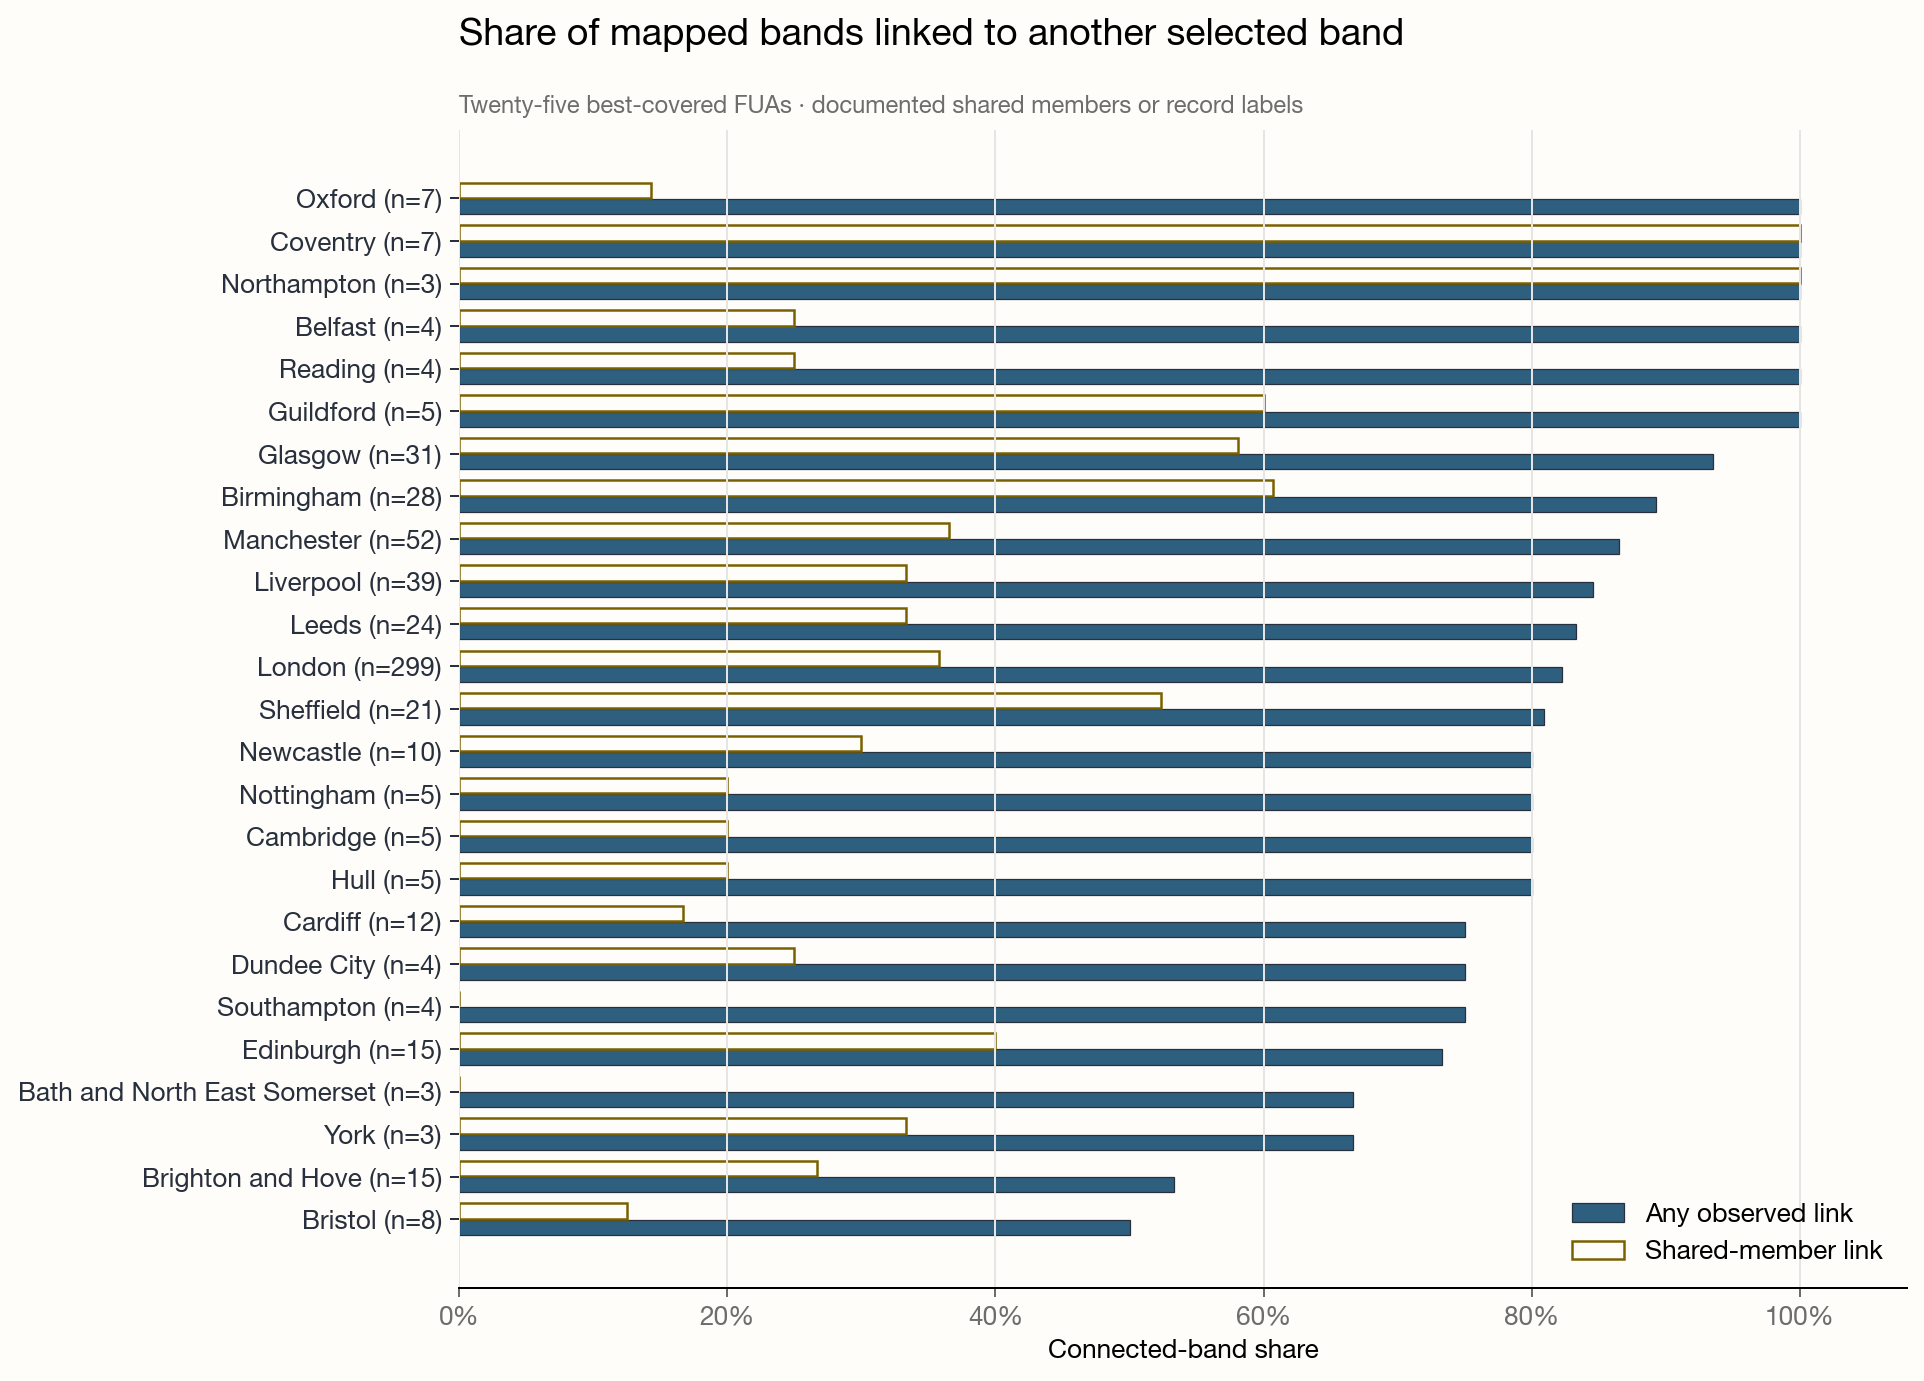

In [4]:
share_path = plot_network_connected_share(
    city_network,
    output_path=ARTIFACT_DIR / "chart_01_connected_band_share.png",
)
display(Image(filename=str(share_path)))

### 2. Where do observed links stay within a city or cross city boundaries?

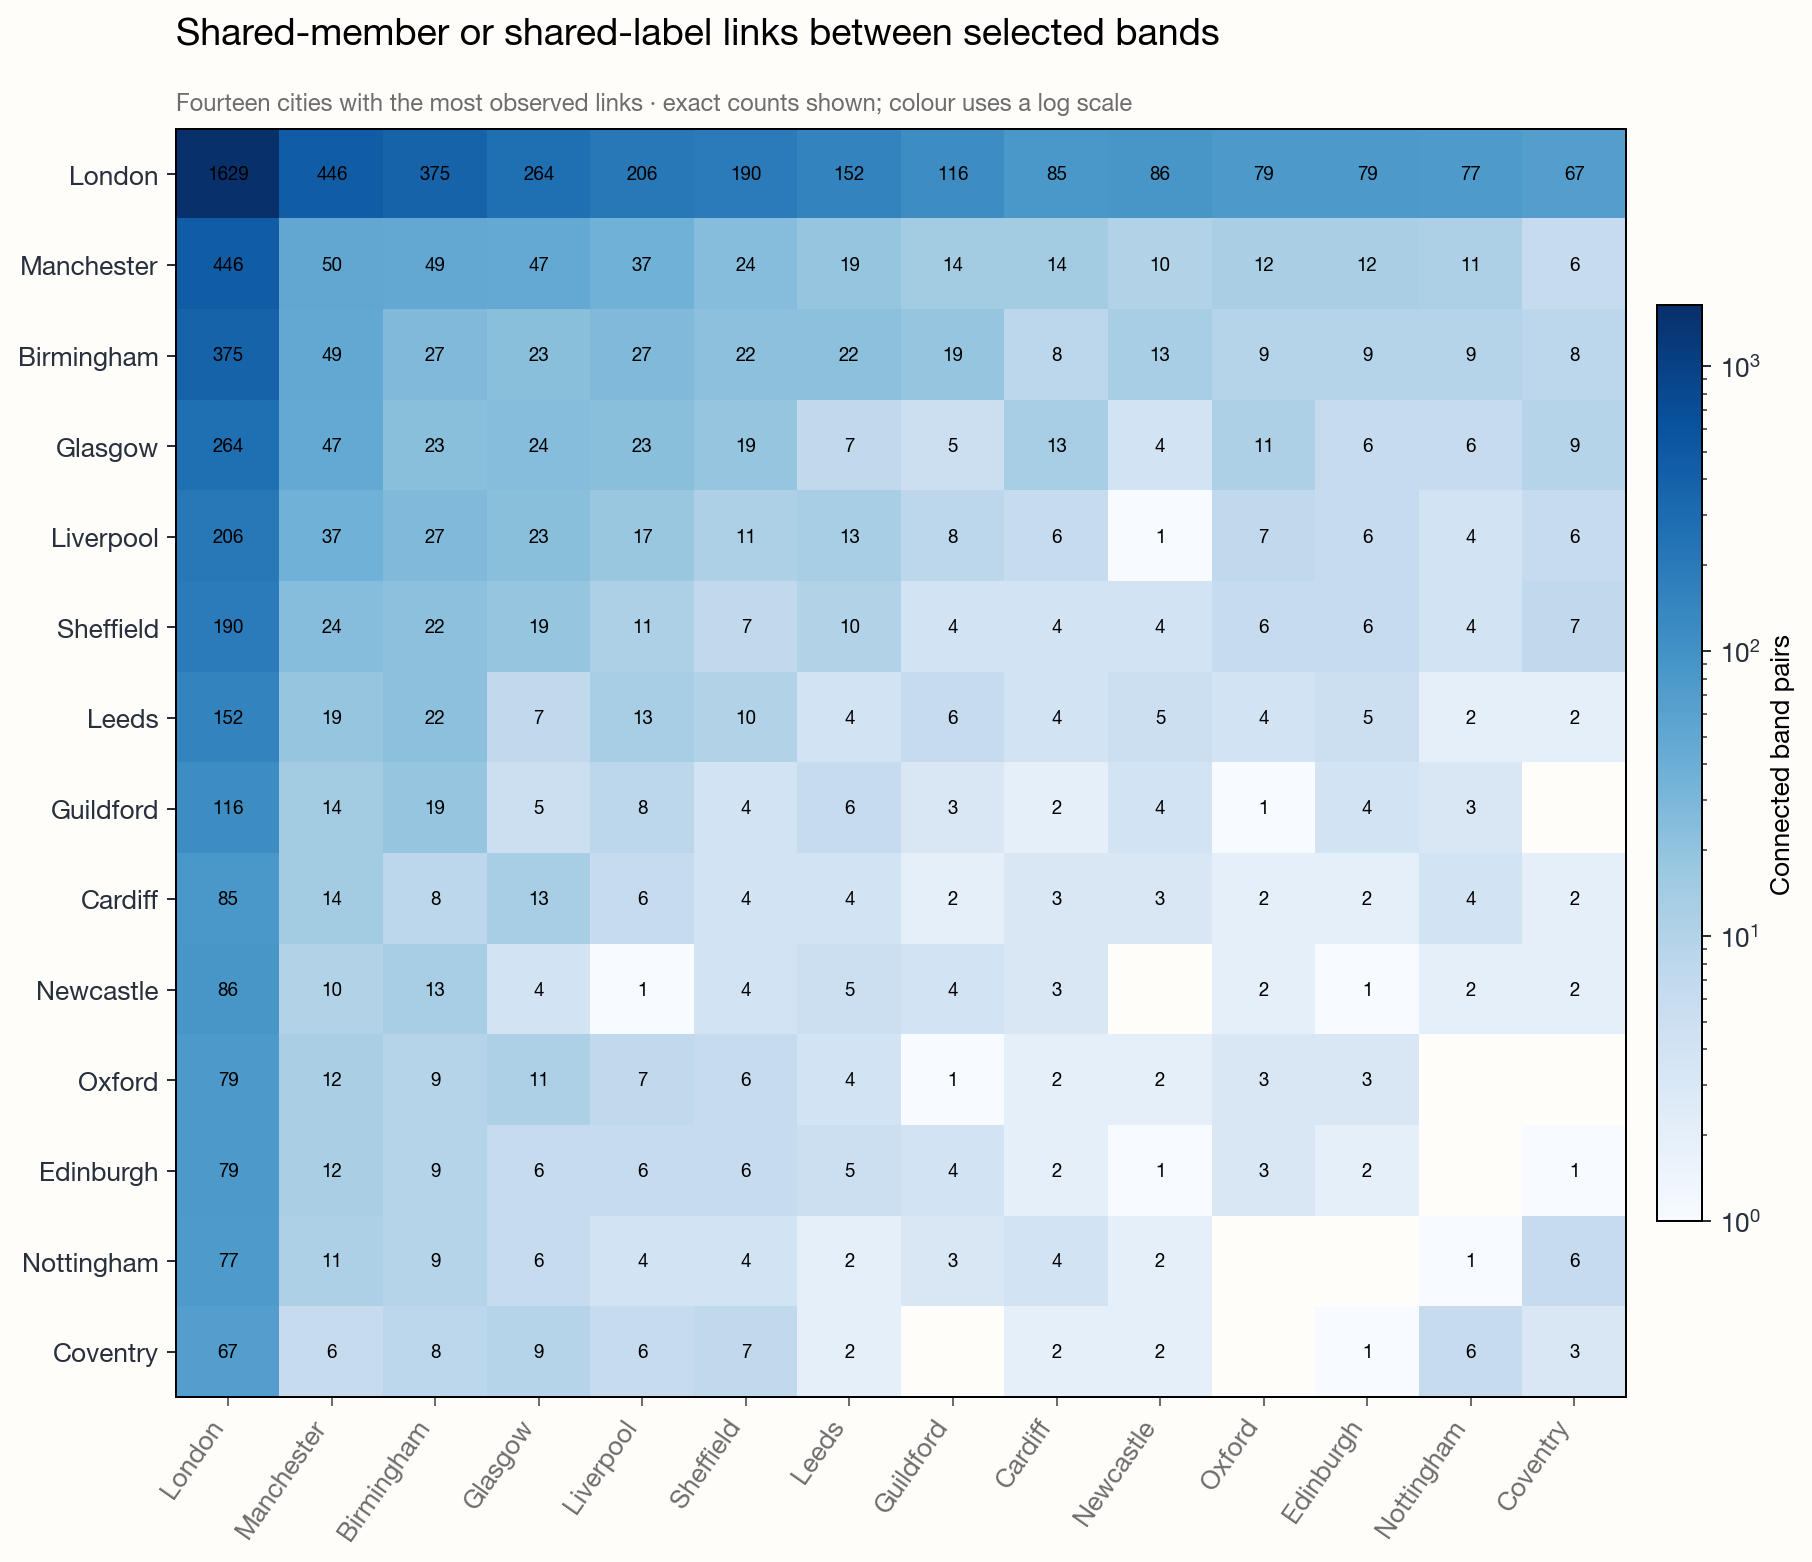

In [5]:
matrix_path = plot_network_city_matrix(
    city_matrix,
    output_path=ARTIFACT_DIR / "chart_02_city_connection_matrix.png",
)
display(Image(filename=str(matrix_path)))

## Takeaways

- Shared-member connections are relatively rare and substantively stronger
  evidence of lineage than shared-label connections.
- Joy Division/New Order, Fun Boy Three/The Specials, Sisters of Mercy/The
  Mission and Heaven 17/The Human League are prominent within-city examples.
- Record-label links dominate the graph and often cross city boundaries,
  describing industry structure more than local scene interaction.
- Coverage differences are large enough that zero-link cities cannot be
  interpreted as having no networks.